In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [ ]:
import zipfile
import os

# Extract train.zip
with zipfile.ZipFile('/content/drive/MyDrive/train.zip', 'r') as z:
    z.extractall('.')

# Extract test.zip
with zipfile.ZipFile('/content/drive/MyDrive/test.zip', 'r') as z:
    z.extractall('.')

print('✅ Files extracted!')
print('Train folders:', os.listdir('train'))
print('Test folders:', os.listdir('test'))

✅ Files extracted!
Train folders: ['surprised', 'neutral', 'angry', 'disgusted', 'fearful', 'happy', 'sad']
Test folders: ['surprised', 'neutral', 'angry', 'disgusted', 'fearful', 'happy', 'sad']


Install & Import Libraries

In [ ]:
!pip install tensorflow numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import 5
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('✅ Libraries imported!')

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Libraries imported!


Configuration

In [ ]:
TRAIN_DIR  = 'train'
TEST_DIR   = 'test'
NUM_TRAIN  = 28709
NUM_VAL    = 7178
BATCH_SIZE = 64
NUM_EPOCH  = 50
IMG_SIZE   = 48
CLASSES    = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

STRESS_EMOTIONS     = ['angry', 'disgusted', 'fearful', 'sad']
NON_STRESS_EMOTIONS = ['happy', 'neutral', 'surprised']

print('✅ Config set!')
print(f'Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {NUM_EPOCH}')
print(f'Classes    : {CLASSES}')

✅ Config set!
Image size : 48x48
Batch size : 64
Epochs     : 50
Classes    : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


Load Dataset

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=CLASSES
)
validation_generator = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=CLASSES
)
print(f'\n✅ Data loaded!')
print(f'Train samples : {train_generator.samples}')
print(f'Test samples  : {validation_generator.samples}')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

✅ Data loaded!
Train samples : 28709
Test samples  : 7178


Build CNN Model

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Classifier
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model.summary()
print('\n✅ Model built!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,345,607 (8.95 MB)

 Trainable params: 2,345,607 (8.95 MB)

 Non-trainable params: 0 (0.00 B)


✅ Model built!


Train Model (Takes ~30-40 mins on GPU)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save best model to Drive automatically
callbacks = [
    ModelCheckpoint(
        '/content/drive/MyDrive/model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print('=== TRAINING STARTED ===')
history = model.fit(
    train_generator,
    steps_per_epoch=NUM_TRAIN // BATCH_SIZE,
    epochs=NUM_EPOCH,
    validation_data=validation_generator,
    validation_steps=NUM_VAL // BATCH_SIZE,
    callbacks=callbacks
)
print('\n✅ Training complete!')

=== TRAINING STARTED ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2449 - loss: 1.8344
Epoch 1: val_accuracy improved from -inf to 0.30901, saving model to /content/drive/MyDrive/model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.2449 - loss: 1.8343 - val_accuracy: 0.3090 - val_loss: 1.7514
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3125 - loss: 1.7816

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

448/448 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6506 - loss: 0.9396 - val_accuracy: 0.5942 - val_loss: 1.0836
Epoch 42/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6094 - loss: 1.0492
Epoch 42: val_accuracy improved from 0.59417 to 0.59459, saving model to /content/drive/MyDrive/model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6094 - loss: 1.0492 - val_accuracy: 0.5946 - val_loss: 1.0825
Epoch 43/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6666 - loss: 0.9030
Epoch 43: val_accuracy did not improve from 0.59459
448/448 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.6666 - loss: 0.9031 - val_accuracy: 0.5908 - val_loss: 1.0880
Epoch 44/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7031 - loss: 0.8512
Epoch 44: val_accuracy did not improve from 0.59459
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7031 - loss: 0.8512 - val_accuracy: 0.5901 - val_loss: 1.0879
Epoch 45/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6708 - loss: 0.8918
Epoch 45: val_accuracy improved from 0.59459 to 0.59807, saving model to /content/drive/MyDrive/model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.6708 - loss: 0.8918 - val_accuracy: 0.5981 - val_loss: 1.0784
Epoch 46/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5469 - loss: 1.0445
Epoch 46: val_accuracy did not improve from 0.59807
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5469 - loss: 1.0445 - val_accuracy: 0.5967 - val_loss: 1.0746
Epoch 47/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6716 - loss: 0.8862
Epoch 47: val_accuracy did not improve from 0.59807
448/448 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.6716 - loss: 0.8861 - val_accuracy: 0.5977 - val_loss: 1.0718
Epoch 48/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6719 - loss: 0.8290
Epoch 48: val_accuracy did not improve from 0.59807
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6719 - loss: 0.8290 - val_accuracy: 0.5974 - val_loss: 1.0710
Epoch 49/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6804 - loss: 0.8580
Epoch 49: val_accur

448/448 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.6804 - loss: 0.8581 - val_accuracy: 0.6007 - val_loss: 1.0763
Epoch 50/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6562 - loss: 0.8419
Epoch 50: val_accuracy improved from 0.60073 to 0.60142, saving model to /content/drive/MyDrive/model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6562 - loss: 0.8419 - val_accuracy: 0.6014 - val_loss: 1.0748
Restoring model weights from the end of the best epoch: 50.

✅ Training complete!


Plot Accuracy & Loss

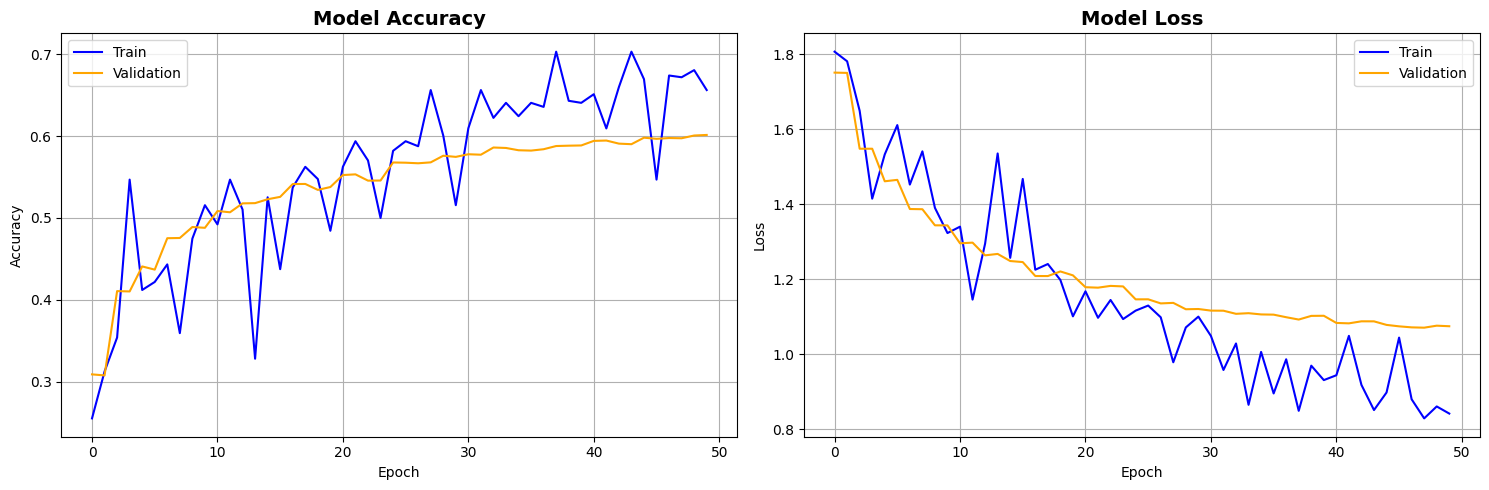

✅ Plot saved to Drive!


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axs[0].plot(history.history['accuracy'], label='Train', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Validation', color='orange')
axs[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()
axs[0].grid(True)

# Loss
axs[1].plot(history.history['loss'], label='Train', color='blue')
axs[1].plot(history.history['val_loss'], label='Validation', color='orange')
axs[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_plot.png', dpi=150)
plt.show()
print('✅ Plot saved to Drive!')


Final Accuracy

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

validation_generator.reset()
loss, accuracy = model.evaluate(validation_generator, verbose=1)

validation_generator.reset()
preds = model.predict(validation_generator, verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = validation_generator.classes

# Binary stress accuracy
binary_true = [1 if CLASSES[c] in STRESS_EMOTIONS else 0 for c in true_classes]
binary_pred = [1 if CLASSES[c] in STRESS_EMOTIONS else 0 for c in pred_classes]
binary_acc  = accuracy_score(binary_true, binary_pred)

print(f'\n{"="*50}')
print(f'  7-CLASS ACCURACY       : {accuracy*100:.2f}%')
print(f'  BINARY STRESS ACCURACY : {binary_acc*100:.2f}%')
print(f'{"="*50}')
print('\nPer-Class Report:')
print(classification_report(true_classes, pred_classes, target_names=CLASSES))

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6073 - loss: 1.0600
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step

  7-CLASS ACCURACY       : 60.11%
  BINARY STRESS ACCURACY : 50.36%

Per-Class Report:
              precision    recall  f1-score   support

       angry       0.15      0.12      0.13       958
   disgusted       0.00      0.00      0.00       111
     fearful       0.13      0.08      0.10      1024
       happy       0.25      0.27      0.26      1774
     neutral       0.17      0.19      0.18      1233
         sad       0.18      0.22      0.20      1247
   surprised       0.12      0.12      0.12       831

    accuracy                           0.18      7178
   macro avg       0.14      0.14      0.14      7178
weighted avg       0.17      0.18      0.18      7178




Download model.h5

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/model.h5')
print('✅ model.h5 downloaded!')
print('Place it in your Flask project folder and run app.py!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ model.h5 downloaded!
Place it in your Flask project folder and run app.py!
